<a href="https://colab.research.google.com/github/agroimpacts/adleo/assignments/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Building CNN-based Semantic Segmentation Model

## Instructions

Please follow the [instructions](assignments-setup.qmd) for setting up, completing, and submitting your assignments.

## Assignment Overview

The focus of this assignment is on building a complete image-to-segmentation modeling pipeline in PyTorch, starting from data loading and ending with training, evaluation, and model interpretation.

After completing this assignment, you will understand how to move from raw image–label pairs to a working deep learning segmentation model, and how architectural design choices affect model behavior and performance.

This assignment is divided into two connected tasks:

1. The first task establishes a solid and reusable pipeline (for image classification);
2. The second task builds on it by requiring you to design, implement, and evaluate your own neural network architecture (for segmentation task).

## Assignment

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise indicated.

### Static code 1

In [3]:
# @title Mount drive and run imports
#from google.colab import drive
#drive.mount("/content/gdrive")

In [2]:
# @title Importing Necessary Packages

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

import torchvision.transforms as transforms
from torchvision.transforms import v2
import torchvision.datasets as datasets
import torch.utils.data as data
import copy

import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
import numbers

import pandas as pd
import os

from pathlib import Path

from torch.utils.data import Dataset, DataLoader
import rasterio

# function to ensure reproducibility by fixing random state
def set_seed(seed_value):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(1)

In [4]:
# @title Save path

train_transforms = v2.Compose([
    v2.RandomRotation(10),
    v2.RandomCrop(28, padding=2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

save_dir = "/Users/gabrielcustodioguzman/Desktop/Adleo/mnist_data/MNIST"
train_dataset = datasets.MNIST(
    root=save_dir,
    train=True,
    download=True,
    transform=train_transforms
)

test_dataset = datasets.MNIST(
    root=save_dir,
    train=False,
    download=False,
    transform=test_transforms
)

total_size = len(train_dataset)
train_size = int(0.9 * total_size)
val_size = total_size - train_size

train_data, val_data = data.random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(1)
)

val_data = copy.deepcopy(val_data)
val_data.dataset.transform = test_transforms

set_seed(1)

train_loader = DataLoader(
    train_data,
    batch_size=50,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=50,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=50,
    shuffle=False
)

100.0%
100.0%
100.0%
100.0%


### Task 1
#### **Use your MNIST dataloader and rrun a torchvision model (ResNet18) for 10 epochs (steps 1.1-1.3)**

In this task you will reuse your MNIST dataloader from Assignment 1 and feed batches into a torchvision ready-to-use model.
To do this, copy/paste your MNIST loading answers (transforms, dataset objects, and dataloaders) from the first assignment into this notebook so you end up with:

- train_loader

- val_loader

- test_loader


Then you will load ResNet18 from torchvision.models, modify the first layer to accept 1-channel MNIST images, and train for 10 epochs while printing the loss per epoch.


#### Step 1.1: Bring your MNIST dataloader and check the image label pairs' shapes


Copy/paste your MNIST answer code from Assignment 1 so that your dataloaders are created in this notebook.
Before moving on, print one batch shape and confirm it looks like:

images: `torch.Size([50, 1, 28, 28])`

labels: `torch.Size([50])`

In [ ]:
## MNIST transforms, Dataset Objects, and Dataloaders

In [5]:
## check the shapes (run unchanged)
batch_t, batch_y = next(iter(train_loader))

print("Image batch shape:", batch_t.shape)
print("Label batch shape:", batch_y.shape)

Image batch shape: torch.Size([50, 1, 28, 28])
Label batch shape: torch.Size([50])


#### Step 1.2: Load and adapt ResNet18 for MNIST


Load ResNet18 from `torchvision.models` with no pretrained weights (`weights=None`) and inspect the architecture.

Identify the following two components in the printed model:

- the first convolution layer (conv1)

- the final fully-connected classification layer (fc)

ResNet18 is originally designed for ImageNet:

- it expects 3-channel (RGB) input

- it outputs 1000 classes

**Since MNIST uses 1-channel images and has 10 classes, you must modify both layers before training.**


> **Required modifications**
>
> - To the input layer (conv1)
>     - Replace `model.conv1` with a new convolution layer so that:
>
>          - in_channels = 1
>          - out_channels stays the same as the original ResNet18
>          - kernel_size, stride, padding, and bias remain unchanged
>
> - To the output layer (fc):
>
>     - Replace `model.fc` with a new fully connected layer so that:
>         - input features = `model.fc.in_features`
>         - output features = 10
>
> **Checking your work**
>
> - Print `model.conv1` and confirm it now accepts 1 input channel
> - Print `model.fc` and confirm the output dimension is 10
>
> Do not proceed to training until both checks are correct.

In [6]:
model = models.resnet18(weights=None)

model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=10
)

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Step 1.3: Train the model for 10 epochs

Once your sanity check passes, train the model for 10 epochs.

> **Requirements**
>
> - Move the model and batches to the same device (CPU or CUDA)
> (Example: define device, then `model = model.to(device)`.)
>
> - Use `nn.CrossEntropyLoss()` as the loss function
>
> - Use `torch.optim.Adam` as the optimizer
>
> - Train for 10 epochs (e.g., `num_epochs = 10`)
>
> - Print average training loss per epoch (one line per epoch)
>
> - Save the training and validation loss values for each epoch so they can be written to a CSV file after training
>
> - Save your trained model at the end of training using: `torch.save(model.state_dict(), "model.pth")`
>
> **Training loop reminders (what happens in each iteration)**
>
> - Call `model.train()` at the beginning of each epoch (enables training behavior)
> - Set `running_loss = 0.0` to accumulate loss across the whole epoch
> - For each batch (this is a nested loop):
>     - move `batch_t` and `batch_y` to the same device as the model
>     - call `optimizer.zero_grad()` before `loss.backward()` (why? because gradients accumulate by default in PyTorch; if you don’t reset them, each step adds on top of the previous step)
>     - compute logits with a forward pass: `logits = model(batch_t)`
>     - compute loss: `loss = criterion(logits, batch_y)`
>     - backpropagate: `loss.backward()`
>     - update weights: `optimizer.step()`
>     - (You have now completed an iteration!)
>     - Make sure to accumulate the total loss of each batch using a `running_loss` variable within the batch loop
> - Compute epoch loss as the average over all samples in the dataset (this should be done at the end of the epoch loop)
> - Validation loss: At the end of each epoch, compute validation loss using:
>    - `model.eval()` (turns off training-specific behavior)
>    - `torch.no_grad()` (saves memory and compute; no gradients needed)
> - Saving loss values:
>     - At the end of each epoch, store the training loss and validation loss in a variable or list
>     - After all epochs are finished, save these values into a CSV file for later visualization
>
> - Saving the model:
>     - After all epochs are finished (after training and evaluation), save your trained model weights using:
`torch.save(model.state_dict(), "resnet18_mnist.pth")`
>
>

> **Output requirements**
>
> Your notebook must:
> 1. Display 10 loss values, one per epoch (15 points for training loop and 5 points for validation loop)
>> It should look something like this using below print statement:

```
print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} |"\f" Val Loss: {val_loss:.4f}")
```

>>```
>> Epoch 1/10 | Train Loss: 0.1943 | Val Loss: 0.0962
>> Epoch 2/10 | Train Loss: 0.0872 | Val Loss: 0.0710
>> Epoch 3/10 | Train Loss: 0.0693 | Val Loss: 0.0474
>> Epoch 4/10 | Train Loss: 0.0590 | Val Loss: 0.0402
>> Epoch 5/10 | Train Loss: 0.0557 | Val Loss: 0.0432
>> Epoch 6/10 | Train Loss: 0.0471 | Val Loss: 0.0407
>> Epoch 7/10 | Train Loss: 0.0444 | Val Loss: 0.0557
>> Epoch 8/10 | Train Loss: 0.0408 | Val Loss: 0.0345
>> Epoch 9/10 | Train Loss: 0.0381 | Val Loss: 0.0267
>> Epoch 10/10 | Train Loss: 0.0356 | Val Loss: 0.0329
>> ```
> 2. Generate a CSV file containing the training and validation loss history (5 points)
> 3. Save the trained model file (.pth) (5 points)
> 4. Read the CSV file and plot the training and validation loss curves (5 points)
>> Your plot should look similar to this:
>> 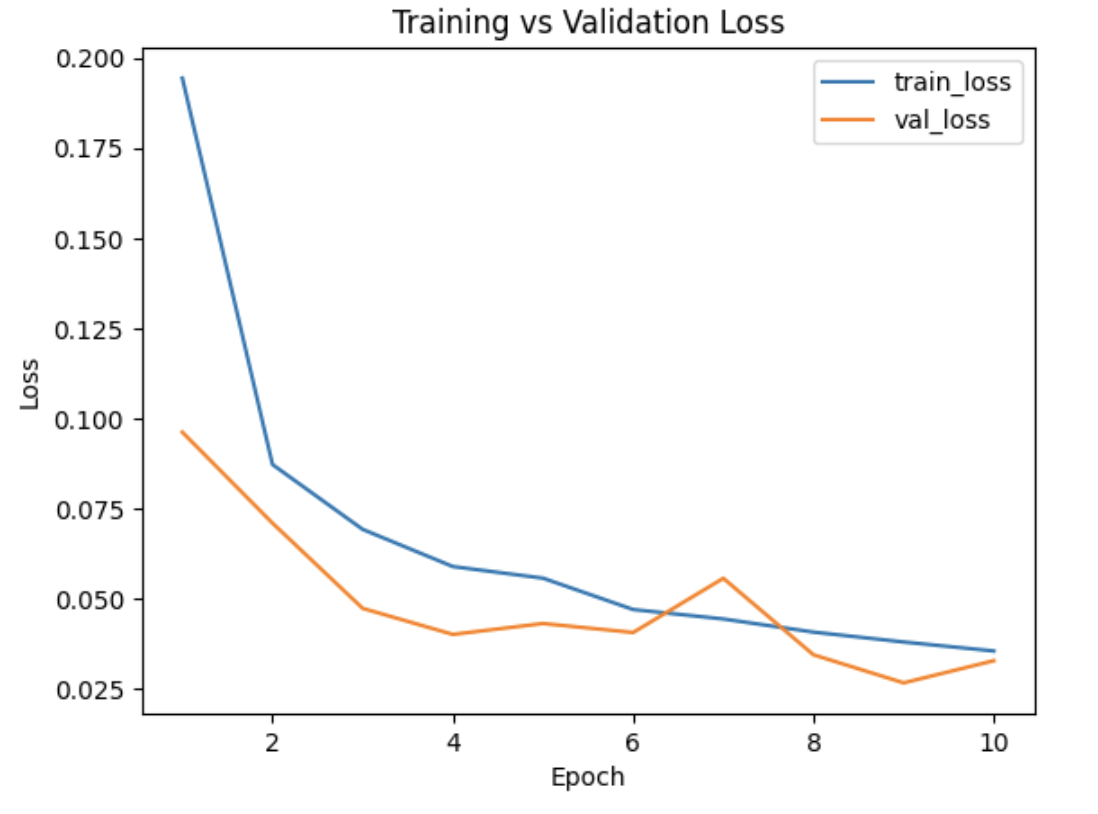

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

num_epochs = 10

max_train_batches = 100
max_val_batches = 30

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx >= max_train_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / max_train_batches
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):

            if batch_idx >= max_val_batches:
                break

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / max_val_batches
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch 1/10, Train Loss: 0.1195, Val Loss: 0.0673
Epoch 2/10, Train Loss: 0.1035, Val Loss: 0.0517
Epoch 3/10, Train Loss: 0.0970, Val Loss: 0.0472
Epoch 4/10, Train Loss: 0.0873, Val Loss: 0.0489
Epoch 5/10, Train Loss: 0.0794, Val Loss: 0.0524
Epoch 6/10, Train Loss: 0.0718, Val Loss: 0.0612
Epoch 7/10, Train Loss: 0.0816, Val Loss: 0.0571
Epoch 8/10, Train Loss: 0.0773, Val Loss: 0.0761
Epoch 9/10, Train Loss: 0.0869, Val Loss: 0.0656
Epoch 10/10, Train Loss: 0.0785, Val Loss: 0.0670


In [9]:
train_df = pd.DataFrame({
    "epoch": range(1, num_epochs + 1),
    "train_loss": train_losses,
    "val_loss": val_losses
})

train_df.to_csv("losses.csv", index=False)

print("CSV saved.")

CSV saved.


In [10]:
torch.save(model.state_dict(), "resnet18_mnist.pth")

print("Model saved.")

Model saved.


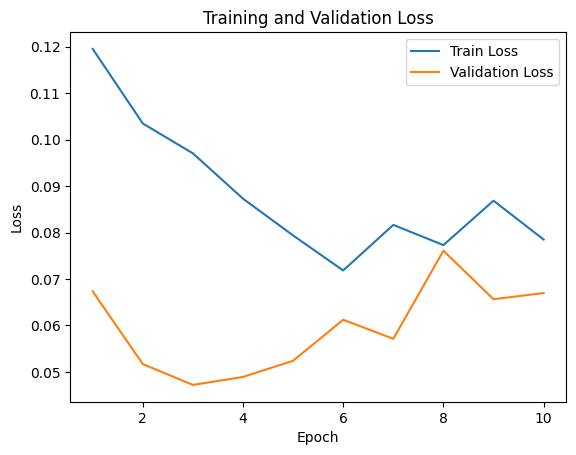

In [11]:
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")

plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()


### Task 2

**Design a U-Net and feed your custom dataset into it (step 2.1-2.4)**

In this task, you will design and implement your own U-Net-style semantic segmentation model, load your custom dataset (images + masks(labels)), and train/evaluate it using the same workflow you used in Task 1
(i.e., dataloaders → model → training loop → validation → save results).

> **What your U-Net must include (requirements)**
>
> Your model must be a real “U-Net family” architecture with:
>
> - Encoder/backdone (downsampling path) with at least 5 levels
>     - “5 levels” means 5 blocks in the encoder (depth ≥ 5).
>     - You must include downsampling between levels (e.g., MaxPool2d(2) or strided conv).
> - Skip connections
>     - Connect encoder features to decoder features at matching spatial sizes (classic U-Net concatenation or addition).
> - Bottleneck
>     - A middle block between encoder and decoder (lowest resolution, highest channels).
> - Decoder (upsampling path)
>     - Must include upsampling (e.g., ConvTranspose2d OR Upsample + Conv2d)
> - Must “recover” resolution step-by-step back to the original size.
> - Final prediction layer :
>     - Output shape must match your segmentation target: `output channels = num_classes`



#### Step 2.1: Bring your Custom Dataloader

Copy your custom dataset, loader and all the necessary functions (Augmentation/normalization,...) in here

In [24]:
class ActiveLoadingDatasetDirect(Dataset):
    """
    Directory-driven dataset for already-chipped remote sensing imagery.
    """

    def __init__(self, src_dir, split,
                 train_ratio=0.8, seed=42,
                 apply_normalization=True, transform=None,
                 image_suffix=".tif", label_suffix=".tif",
                 **kargs):

        self.src_dir = Path(src_dir) / "mappingafrica-256"

        self.transform = transform
        self.apply_normalization = apply_normalization

        self.split = split
        assert self.split in ["train", "validate"], "Split is not recognized."

        img_dir = self.src_dir / "images"
        lbl_dir = self.src_dir / "labels"

        img_files = sorted(img_dir.glob(f"*{image_suffix}"))
        lbl_files = sorted(lbl_dir.glob(f"*{label_suffix}"))

        lbl_lookup = {
            (parts[0], parts[-1]): lp
            for lp in lbl_files
            for parts in [lp.stem.split("_")]
        }

        all_pairs = []

        for ip in img_files:
            parts = ip.stem.split("_")
            key = (parts[0], parts[-1])

            if key in lbl_lookup:
                all_pairs.append((ip, lbl_lookup[key]))

        rng = np.random.default_rng(seed)

        perm = rng.permutation(len(all_pairs))

        n_train = int(len(all_pairs) * train_ratio)

        train_idx = perm[:n_train]
        valid_idx = perm[n_train:]

        if self.split == "train":
            self.pairs = [all_pairs[i] for i in train_idx]
        else:
            self.pairs = [all_pairs[i] for i in valid_idx]

        self.images = []
        self.labels = []

        for img_path, lbl_path in self.pairs:

            with rasterio.open(img_path) as src:
                img = src.read()

            img = np.transpose(img, (1, 2, 0))

            with rasterio.open(lbl_path) as src:
                label = src.read(1)

            if self.apply_normalization:
                img = min_max_normalize_image(
                    np.transpose(img, (2, 0, 1))
                )

                img = np.transpose(img, (1, 2, 0))

            self.images.append(img)
            self.labels.append(label)

    def __getitem__(self, index):

        img = self.images[index].copy()
        label = self.labels[index].copy()

        if self.split == "train" and self.transform:

            if random.randint(0, 1) and "rotate" in self.transform:
                img, label = rotate_image_and_label(
                    img,
                    label,
                    angle=[-10, 10]
                )

            if random.random() > 0.5 and "flip" in self.transform:

                flip_type = random.choice(["hflip", "vflip"])

                img, label = flip_image_and_label(
                    img,
                    label,
                    flip_type
                )

        image_tensor = torch.from_numpy(
            np.ascontiguousarray(
                img.transpose((2, 0, 1))
            )
        ).float()

        label_tensor = torch.from_numpy(
            np.ascontiguousarray(label)
        ).long()

        return image_tensor, label_tensor

    def __len__(self):
        return len(self.pairs)
set_seed(1)

train_dataset = ActiveLoadingDatasetDirect(
    src_dir="/Users/gabrielcustodioguzman/Desktop/Adleo",
    split="train",
    transform=["rotate", "flip"]
)

validate_dataset = ActiveLoadingDatasetDirect(
    src_dir="/Users/gabrielcustodioguzman/Desktop/Adleo",
    split="validate",
    transform=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    validate_dataset,
    batch_size=4,
    shuffle=False
)

ValueError: num_samples should be a positive integer value, but got num_samples=0

#### Step 2.2: U-Net implementation

Implement your model (You can check the lab materials if need to recall)


In [ ]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.enc5 = DoubleConv(512, 1024)

        # Decoder
        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec4 = DoubleConv(128, 64)

        # Final output
        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        bottleneck = self.enc5(p4)

        # Decoder
        d1 = self.up1(bottleneck)
        d1 = torch.cat([d1, e4], dim=1)
        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e3], dim=1)
        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e2], dim=1)
        d3 = self.dec3(d3)

        d4 = self.up4(d3)
        d4 = torch.cat([d4, e1], dim=1)
        d4 = self.dec4(d4)

        return self.final(d4)


In [ ]:
model = UNet(in_channels=3, num_classes=2)

print(model)

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )


#### Step 2.3: Train and validation loop, save the losses and model, and plot loss curve

Reuse the same training loop pattern from Task 1 to train the model for 10 epochs. Your code should include:

> - device = ...
> - `model.to(device)`
> - `optimizer = Adam(...)`
> - epoch loop:
>     - model.train()
>     - forward → loss → backward → step
>     - validation each epoch:
>         - model.eval() + torch.no_grad()
>     - store:
>         - train_loss_per_epoch
>         - val_loss_per_epoch
>
> - save:
>     - CSV of losses
>     - model weights (torch.save(model.state_dict(), "...pth"))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

train_losses = []
val_losses = []

num_epochs = 10

max_train_batches = 50
max_val_batches = 20

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx >= max_train_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / max_train_batches
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for batch_idx, (images, labels) in enumerate(val_loader):

            if batch_idx >= max_val_batches:
                break

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / max_val_batches
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}"
    )

RuntimeError: Given groups=1, weight of size [64, 3, 3, 3], expected input[50, 1, 28, 28] to have 3 channels, but got 1 channels instead

In [ ]:
loss_df = pd.DataFrame({
    "epoch": range(1, num_epochs + 1),
    "train_loss": train_losses,
    "val_loss": val_losses
})

loss_df.to_csv("unet_losses.csv", index=False)

print("CSV saved.")

In [ ]:
torch.save(model.state_dict(), "unet_segmentation_model.pth")

print("Model saved.")

In [ ]:
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net Training and Validation Loss")
plt.legend()

plt.show()

#### Step 2.4: Create a clean diagram of your U-Net

And then paste it into the notebook.

> **Requirements**
>
> - Your diagram must show:
>     - encoder levels (≥ 5)
>     - skip connections
>     - bottleneck
>     - decoder levels
>
> - Make it readable
>     - Have clear labels naming the key components
>     - Channel sizes are optional to provide but nice to have
>
> **How to do make and present your figure**
> - Use one of these to make your figure:
>     - PowerPoint
>      - Keynote
>     - Google Slides
>     - draw.io
>     - Figma
> - Once completed, export diagram as image → paste into notebook Markdown (cell below).

#### What should my results look like?

Since each of you are building your own model, there will be variations in what expected outputs look like, so we are not providing examples here. However, the outputs from the previous task give a guide for what the outputs should look like from a functioning U-Net. There are many examples of functional U-Nets online, and your agent will be able to readily design a functional U-Net for you. If it works, when you feed data into it and train it, it should produce train and validation loss outputs for each iteration, showing a general pattern of decline similar to those from the ResNet applied to MNIST in Task 1.

In [ ]:
Image seperate